# Save result pic as videos

In [10]:
import os
import cv2
from tqdm import tqdm

# folders
camera_pic_folders = ['randla_1', 'step_1', 'combine_1']
output_folder = 'videos'  # where the .mp4 files will be written
os.makedirs(output_folder, exist_ok=True)

# parameters
fps = 16  # frames per second for the output video
# try 'mp4v' first; if your player can't open the result, try 'avc1' (H.264) or switch to .avi with 'XVID'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

def numeric_key(fn):
    """Sort by the numeric filename (without extension); fall back to lexicographic."""
    name, _ = os.path.splitext(fn)
    try:
        return int(name)
    except ValueError:
        return name  # fallback for non-numeric

for current_folder in tqdm(camera_pic_folders, desc="Building videos", unit="folder"):
    if not os.path.isdir(current_folder):
        print(f"Skip: '{current_folder}' is not a directory.")
        continue

    # each subfolder in current_folder becomes one video
    list_subfolders = [d for d in os.listdir(current_folder)
                       if os.path.isdir(os.path.join(current_folder, d))]
    if not list_subfolders:
        print(f"No subfolders found in '{current_folder}'.")
        continue

    for sub in tqdm(list_subfolders, desc=f"Building {current_folder}", unit="subfolder"):
        cam_dir = os.path.join(current_folder, sub)
        files = sorted(
            [f for f in os.listdir(cam_dir) if f.lower().endswith('.png')],
            key=numeric_key
        )

        if not files:
            print(f"No .png files in '{cam_dir}'. Skipping.")
            continue

        # determine frame size (W, H) correctly
        first_path = os.path.join(cam_dir, files[0])
        first_img = cv2.imread(first_path, cv2.IMREAD_COLOR)
        if first_img is None:
            print(f"Cannot read first image: {first_path}. Skipping.")
            continue
        H, W = first_img.shape[:2]  # shape returns (H, W, C)
        frame_size = (W, H)         # VideoWriter expects (width, height)

        # create output path mirroring current_folder structure
        out_dir = os.path.join(output_folder, current_folder)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f'{sub}.mp4')

        writer = cv2.VideoWriter(out_path, fourcc, fps, frame_size)
        if not writer.isOpened():
            print(f"Failed to open writer for: {out_path}")
            continue

        # write frames
        wrote = 0
        for fn in (files):
            img_path = os.path.join(cam_dir, fn)
            frame = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if frame is None:
                print(f"Warning: couldn't read {img_path}; skipping.")
                continue
            if frame.shape[1] != W or frame.shape[0] != H:
                # resize mismatched frames to the target size
                frame = cv2.resize(frame, frame_size, interpolation=cv2.INTER_AREA)
            writer.write(frame)
            wrote += 1

        writer.release()

        # if wrote == 0:
        #     print(f"No frames written for {out_path}. The video will be empty.")
        #     # optional: os.remove(out_path)
        # else:
        #     print(f"✅ Wrote {wrote} frames to {out_path}")


Building videos:   0%|          | 0/3 [00:04<?, ?folder/s]


KeyboardInterrupt: 

# Combine Videos

In [ ]:
import os
import re
import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# -------- CONFIG --------
VIDEOS_ROOT    = "videos"
GROUPS         = ["step_1", "randla_1", "combine_1"]     # process both groups
OUT_SUBFMT     = "combine_{group}"      # per-group output subfolder
EXPECTED_COUNT = 5                       # we expect _1.._5

# Choose layout: "row" => 1x5, "2x3" => 2x3 grid (one empty slot)
LAYOUT_MODE    = "2x3"                  # "row" or "2x3"

# Visual tuning
TARGET_CELL_W  = 450
TARGET_CELL_H  = 288
GUTTER         = 6
BG_COLOR       = (0, 0, 0)              # BGR

# Labels
DRAW_LABELS    = True                   # turn labels on/off
LABEL_PADDING  = 8                      # inner padding for the label box
LABEL_MARGIN   = 10                     # distance from top-left corner
LABEL_BG_ALPHA = 0.6                    # 0..1 transparency of the label box

# Codec
FOURCC = cv2.VideoWriter_fourcc(*"mp4v")
# ------------------------

pat = re.compile(r"^(?P<base>.+)_(?P<num>[1-9]\d*)\.mp4$", re.IGNORECASE)

def list_basenames_with_parts(group_path):
    parts = defaultdict(list)
    for fn in os.listdir(group_path):
        if not fn.lower().endswith(".mp4"):
            continue
        m = pat.match(fn)
        if not m:
            continue
        base = m.group("base")
        num = int(m.group("num"))
        parts[base].append((num, os.path.join(group_path, fn)))
    for base in list(parts.keys()):
        parts[base].sort(key=lambda x: x[0])
    return parts

def get_layout(mode, count):
    if mode == "row":
        return (1, count)      # 1 x 5
    elif mode == "2x3":
        return (2, 3)          # 2 x 3
    else:
        raise ValueError("LAYOUT_MODE must be 'row' or '2x3'")

def letterbox(frame, target_w, target_h, bg_color):
    h, w = frame.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)
    y0 = (target_h - new_h) // 2
    x0 = (target_w - new_w) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized
    return canvas

def draw_label(img, text):
    """Draw a semi-transparent label box with text in top-left of the tile."""
    if not DRAW_LABELS or text is None:
        return img
    overlay = img.copy()

    # autoscale font relative to cell size
    base = min(img.shape[0], img.shape[1])
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.5, base / 240.0)     # tweak as desired
    thickness = max(1, int(round(base / 200.0)))

    # get text size
    (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    box_w = tw + 2 * LABEL_PADDING
    box_h = th + baseline + 2 * LABEL_PADDING

    x, y = LABEL_MARGIN, LABEL_MARGIN  # top-left corner of box
    # draw semi-transparent filled rectangle on overlay
    cv2.rectangle(overlay, (x, y), (x + box_w, y + box_h), (0, 0, 0), -1)
    # blend overlay with original
    cv2.addWeighted(overlay, LABEL_BG_ALPHA, img, 1 - LABEL_BG_ALPHA, 0, dst=img)

    # draw text in white
    tx = x + LABEL_PADDING
    ty = y + LABEL_PADDING + th
    cv2.putText(img, text, (tx, ty), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
    return img

def stack_grid(frames, rows, cols, cell_w, cell_h, gutter, bg_color):
    total_w = cols * cell_w + (cols - 1) * gutter
    total_h = rows * cell_h + (rows - 1) * gutter
    canvas = np.full((total_h, total_w, 3), bg_color, dtype=np.uint8)
    idx = 0
    for r in range(rows):
        for c in range(cols):
            y = r * (cell_h + gutter)
            x = c * (cell_w + gutter)
            if idx < len(frames) and frames[idx] is not None:
                canvas[y:y+cell_h, x:x+cell_w] = frames[idx]
            idx += 1
    return canvas

def build_grid_video(sources, out_path, layout_mode):
    rows, cols = get_layout(layout_mode, EXPECTED_COUNT)
    slots = rows * cols

    # labels per slot: "1".."len(sources)" then None
    slot_labels = [str(i+1) if i < len(sources) else None for i in range(slots)]

    # open caps (pad to slot count with None)
    caps = []
    for i in range(slots):
        if i < len(sources):
            cap = cv2.VideoCapture(sources[i])
            if not cap.isOpened():
                print(f"⚠ Can't open: {sources[i]}")
                cap = None
        else:
            cap = None
        caps.append(cap)

    base_cap = next((c for c in caps if c is not None), None)
    if base_cap is None:
        return False, "No readable inputs"

    # choose fps from first valid cap (fallback 30)
    fps = base_cap.get(cv2.CAP_PROP_FPS) or 30.0
    for c in caps:
        if c is not None and (c.get(cv2.CAP_PROP_FPS) or 0) > 0:
            fps = c.get(cv2.CAP_PROP_FPS)
            break

    total_w = cols * TARGET_CELL_W + (cols - 1) * GUTTER
    total_h = rows * TARGET_CELL_H + (rows - 1) * GUTTER

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    writer = cv2.VideoWriter(out_path, FOURCC, fps, (total_w, total_h))
    if not writer.isOpened():
        for c in caps:
            if c is not None: c.release()
        return False, f"Failed to open writer: {out_path}"

    # keep last good frame per slot (letterboxed and labeled), for freeze-after-finish
    last_frames = [None] * len(caps)

    total_written = 0
    pbar = tqdm(desc=f"Grid -> {os.path.basename(out_path)}", unit="f")
    while True:
        any_new_frame = False
        cell_frames = []
        for idx, cap in enumerate(caps):
            label_text = slot_labels[idx]
            if cap is None:
                # no source in this slot -> use black (still show label if you want)
                filler = np.full((TARGET_CELL_H, TARGET_CELL_W, 3), BG_COLOR, dtype=np.uint8)
                cell_frames.append(draw_label(filler, label_text))
                continue

            ok, frame = cap.read()
            if ok:
                any_new_frame = True
                boxed = letterbox(frame, TARGET_CELL_W, TARGET_CELL_H, BG_COLOR)
                boxed = draw_label(boxed, label_text)
                last_frames[idx] = boxed
                cell_frames.append(boxed)
            else:
                # freeze on the last good frame; if none yet, use black with label
                if last_frames[idx] is not None:
                    cell_frames.append(last_frames[idx])
                else:
                    filler = np.full((TARGET_CELL_H, TARGET_CELL_W, 3), BG_COLOR, dtype=np.uint8)
                    cell_frames.append(draw_label(filler, label_text))

        # stop when NO input produced a new frame this iteration
        if not any_new_frame:
            break

        grid = stack_grid(cell_frames, rows, cols, TARGET_CELL_W, TARGET_CELL_H, GUTTER, BG_COLOR)
        writer.write(grid)
        total_written += 1
        pbar.update(1)

    pbar.close()
    for c in caps:
        if c is not None: c.release()
    writer.release()
    return True, f"Wrote {total_written} frames @ ~{fps:.2f} FPS, size {total_w}x{total_h}"

def process_group(group):
    group_path = os.path.join(VIDEOS_ROOT, group)
    out_dir = os.path.join(group_path, OUT_SUBFMT.format(group=group))
    os.makedirs(out_dir, exist_ok=True)

    parts_map = list_basenames_with_parts(group_path)
    if not parts_map:
        print(f"No numbered inputs found in {group_path}")
        return

    for base, numbered in parts_map.items():
        numbered.sort(key=lambda x: x[0])
        wanted = [path for num, path in numbered if 1 <= num <= EXPECTED_COUNT]
        if len(wanted) < EXPECTED_COUNT:
            print(f"⚠ {group}/{base}: only {len(wanted)} of {EXPECTED_COUNT} parts found (missing will be black)")
        out_path = os.path.join(out_dir, f"{base}.mp4")
        ok, msg = build_grid_video(wanted, out_path, LAYOUT_MODE)
        print(("✅" if ok else "❌") + f" {group}/{base}: {msg} -> {out_path}")

for group in GROUPS:
    if not os.path.isdir(os.path.join(VIDEOS_ROOT, group)):
        print(f"Skip (no folder): {os.path.join(VIDEOS_ROOT, group)}")
        continue
    process_group(group)


Grid -> hole.mp4: 350f [00:03, 90.87f/s]


✅ step_1/hole: Wrote 350 frames @ ~16.00 FPS, size 1362x582 -> videos\step_1\combine_step_1\hole.mp4


Grid -> normal.mp4: 350f [00:03, 91.90f/s] 


✅ step_1/normal: Wrote 350 frames @ ~16.00 FPS, size 1362x582 -> videos\step_1\combine_step_1\normal.mp4


Grid -> ramp.mp4: 350f [00:03, 91.97f/s]


...

✅ combine_1/ramp_obstacle: Wrote 82 frames @ ~16.00 FPS, size 1362x582 -> videos\combine_1\combine_combine_1\ramp_obstacle.mp4


Grid -> two_height_ramp.mp4: 350f [00:02, 117.53f/s]


✅ combine_1/two_height_ramp: Wrote 350 frames @ ~16.00 FPS, size 1362x582 -> videos\combine_1\combine_combine_1\two_height_ramp.mp4


Grid -> uneven.mp4: 350f [00:03, 105.89f/s]

✅ combine_1/uneven: Wrote 350 frames @ ~16.00 FPS, size 1362x582 -> videos\combine_1\combine_combine_1\uneven.mp4


# Get trajectories


In [ ]:
# Simple trajectory plotter (no argparse)
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ========= user settings =========
# Working dir should be: PythonClient/car/trying/record
ROOT = 'step'         # 'step' or 'randla'
SUBDIRS = None        # e.g., ['hole_1'] or None for all subfolders
MARGIN = 6.0          # same idea as STEP_config['grid_margin']
SAVE_PATH = 'videos/step/trajectories.png'  # or None to just show
SHOW = True
# =================================

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=lambda fn: int(os.path.splitext(fn)[0].split('_')[0]))
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def compute_bounds(paths, margin):
    all_pts = np.vstack(paths)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

root = os.path.abspath(ROOT)
if not os.path.isdir(root):
    raise FileNotFoundError(f'Root folder not found: {root}')

subdirs = SUBDIRS if SUBDIRS is not None else [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

paths, names = [], []
for sub in subdirs:
    run_dir = os.path.join(root, sub)
    if not os.path.isdir(run_dir):
        continue
    traj = load_run_positions(run_dir)
    if traj.shape[0] >= 2:
        paths.append(traj)
        names.append(sub)

if not paths:
    print("No valid trajectories found.")
else:
    xmin, xmax, ymin, ymax = compute_bounds(paths, MARGIN)

    plt.figure(figsize=(8, 8))
    for traj, label in zip(paths, names):
        x = traj[:, 0]
        y = traj[:, 1]
        # Match test_step: plot Y on X-axis, X on Y-axis
        plt.plot(y, x, linewidth=2, label=label)
        plt.scatter(y[0], x[0], c='green', s=30)          # start
        plt.scatter(y[-1], x[-1], c='red', s=30, marker='x')  # end

    plt.xlim(ymin, ymax)
    plt.ylim(xmin, xmax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel('Y (world)')
    plt.ylabel('X (world)')
    plt.title('Car Trajectories (test_step map setting)')
    plt.legend()

    # if SAVE_PATH:
    #     os.makedirs(os.path.dirname(os.path.abspath(SAVE_PATH)), exist_ok=True)
    #     plt.savefig(SAVE_PATH, dpi=200, bbox_inches='tight')
    #     print(f"Saved figure to: {SAVE_PATH}")
    # if SHOW or not SAVE_PATH:
    plt.show()

In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt

# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOT = 'randla'    # 'randla' or 'step'
MARGIN = 6.0       # like STEP_config['grid_margin']
SAVE_DIR = 'videos/randla/trajectories_per_env_grouped'
SHOW = True
# =====================

def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def base_env(name):
    # strip a single trailing _<digits>
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

root = os.path.abspath(ROOT)
if not os.path.isdir(root):
    raise FileNotFoundError(f'Root folder not found: {root}')

subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
# Group by base environment (e.g., hole_1, hole_2 -> hole)
groups = {}
for sub in subdirs:
    key = base_env(sub)
    groups.setdefault(key, []).append(sub)

os.makedirs(SAVE_DIR, exist_ok=True)

for env_name, runs in sorted(groups.items()):
    trajs, labels = [], []
    for run in sorted(runs):
        run_dir = os.path.join(root, run)
        traj = load_run_positions(run_dir)
        if traj.shape[0] >= 2:
            trajs.append(traj)
            labels.append(run)

    if not trajs:
        print(f"Skip (no data): {env_name}")
        continue

    xmin, xmax, ymin, ymax = bounds_with_margin(trajs, MARGIN)

    plt.figure(figsize=(7, 7))
    for traj, label in zip(trajs, labels):
        x = traj[:, 0]; y = traj[:, 1]
        # Match test_step: plot Y on X-axis, X on Y-axis
        plt.plot(y, x, linewidth=2, label=label)
        plt.scatter(y[0], x[0], c='green', s=25)
        plt.scatter(y[-1], x[-1], c='red', s=25, marker='x')

    plt.xlim(ymin, ymax)
    plt.ylim(xmin, xmax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel('Y (world)')
    plt.ylabel('X (world)')
    plt.title(f'Trajectories - {ROOT}/{env_name}')
    plt.legend(fontsize=8, loc='best')

    out_path = os.path.join(SAVE_DIR, f'{env_name}.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"Saved: {out_path}")
    if SHOW:
        plt.show()
    else:
        plt.close()

open
Saved: videos\randla_1\trajectories_grid_1x5\hole_grid.png


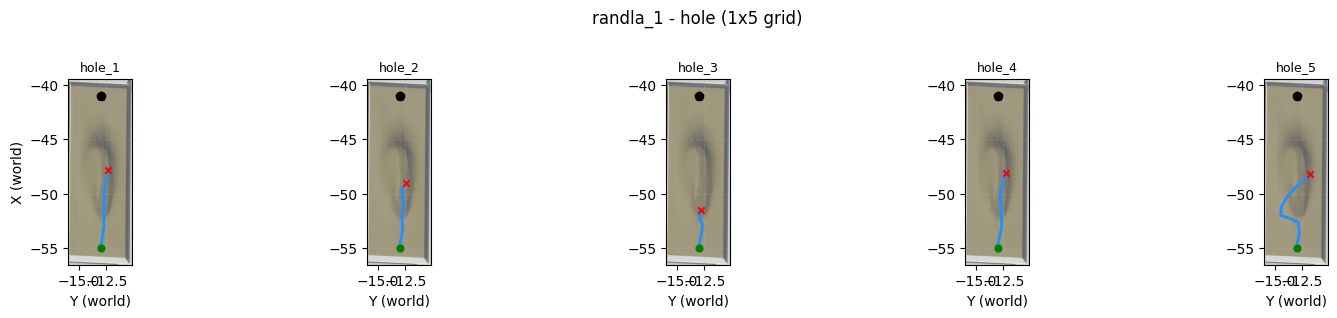

Saved: videos\randla_1\trajectories_grid_1x5\normal_grid.png


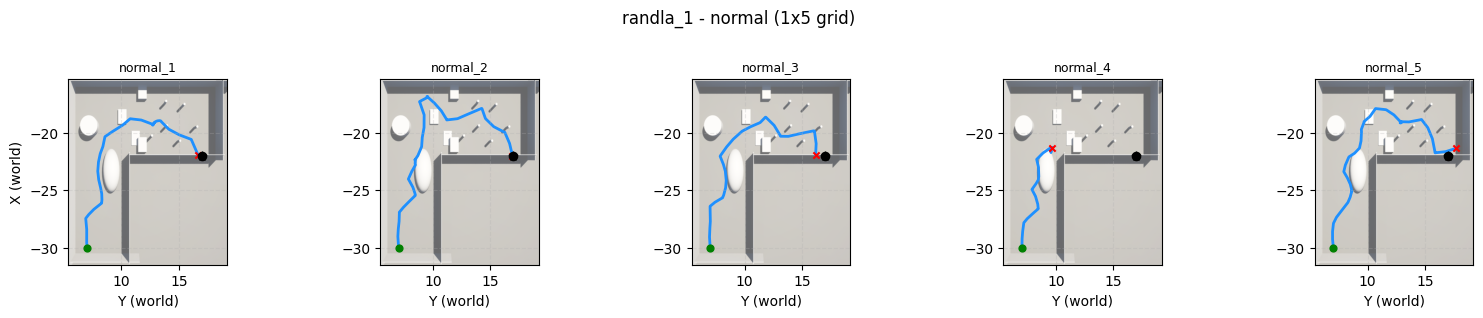

Saved: videos\randla_1\trajectories_grid_1x5\ramp_grid.png


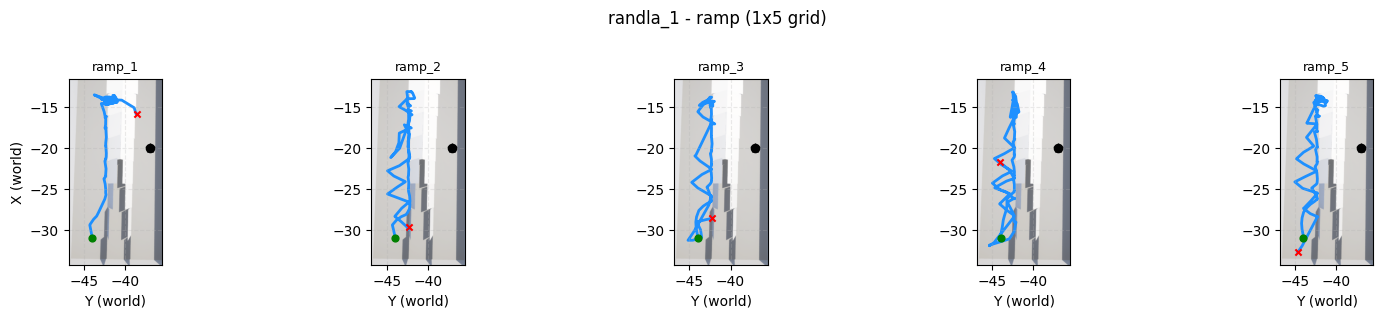

Saved: videos\randla_1\trajectories_grid_1x5\ramp_obstacle_grid.png


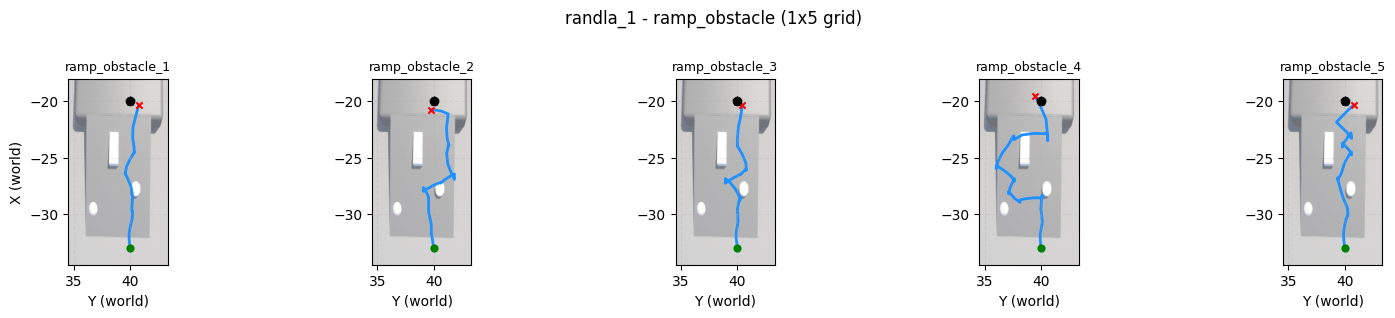

Saved: videos\randla_1\trajectories_grid_1x5\two_height_ramp_grid.png


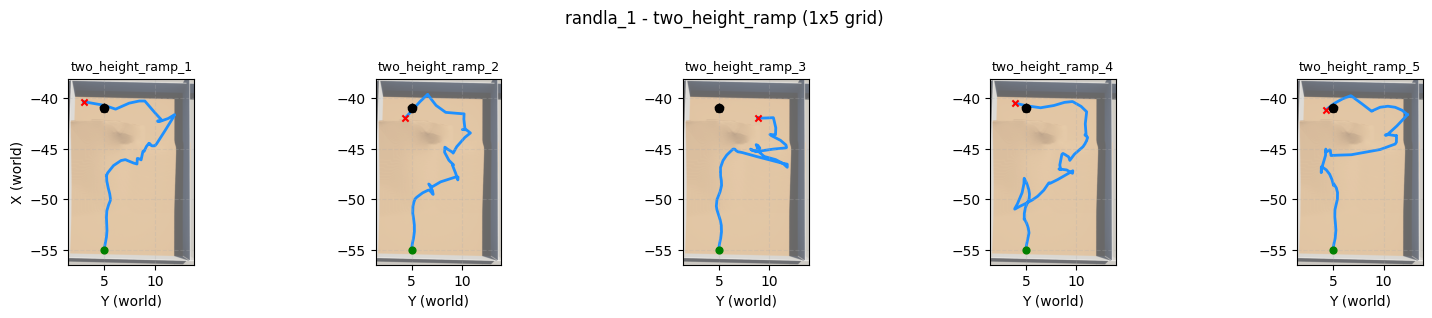

Saved: videos\randla_1\trajectories_grid_1x5\uneven_grid.png


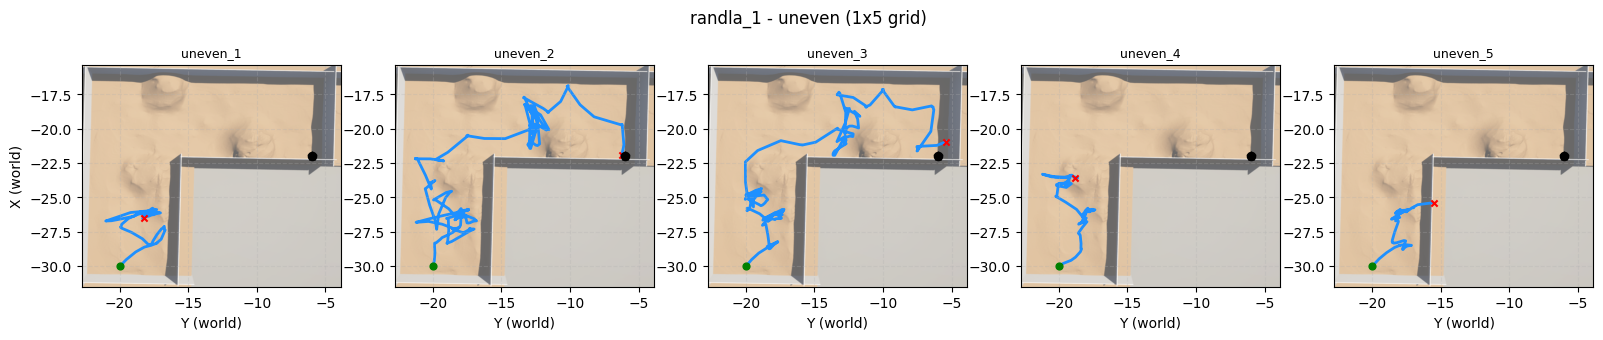

open
Saved: videos\step_1\trajectories_grid_1x5\hole_grid.png


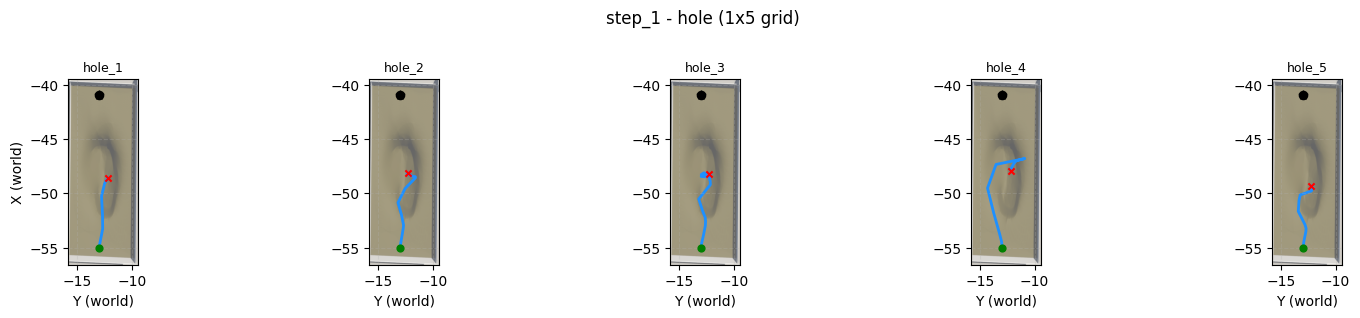

Saved: videos\step_1\trajectories_grid_1x5\normal_grid.png


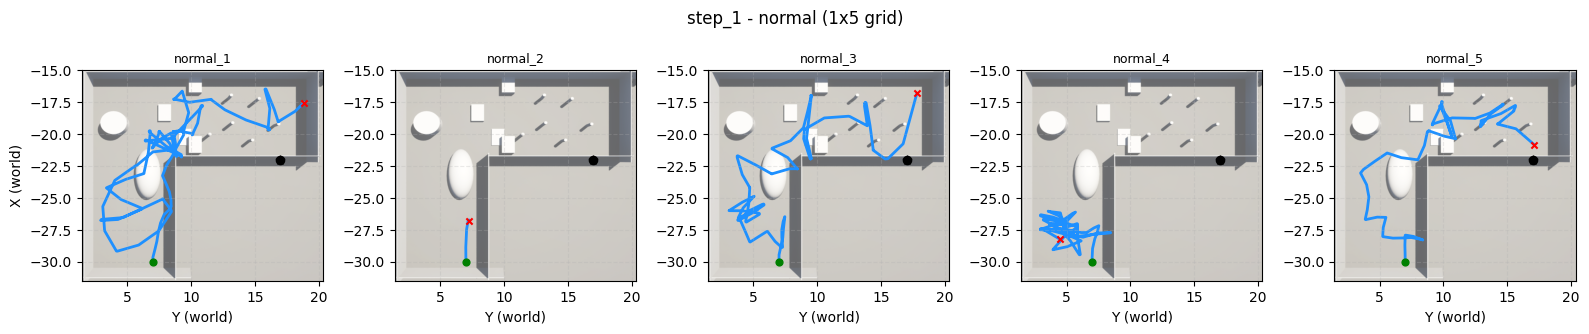

Saved: videos\step_1\trajectories_grid_1x5\ramp_grid.png


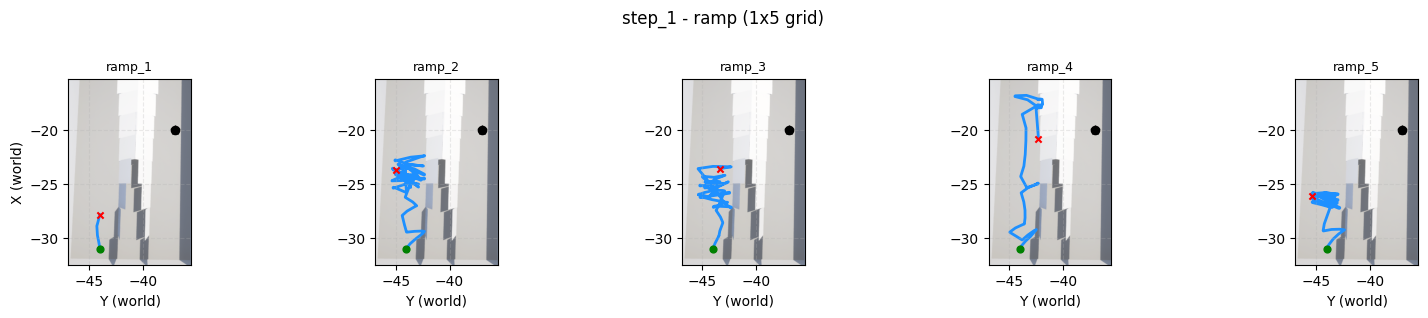

In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from math import ceil

# ===== settings =====
# Working dir should be PythonClient/car/trying/record
ROOTS = ['randla_1', 'step_1', 'combine_1']
MARGIN = 1.5      # like STEP_config['grid_margin']
SAVE_SUBDIR = 'trajectories_grid_1x5'   # goes under videos/<root>/
BG_DIR = 'image'   # background images folder (e.g., image/hole.png)
BG_ALPHA = 0.6     # transparency of background
FLIP_BG_HORIZ = True
SHOW = True
# =====================

def round_pair(p):
    try:
        return (int(round(float(p[0]))), int(round(float(p[1]))))
    except Exception:
        return None

def load_goal_map(stats_path):
    m = {}
    if not os.path.exists(stats_path):
        return m
    try:
        with open(stats_path, 'r') as fh:
            data = json.load(fh)
            print("open")
        for rec in data:
            sp = rec.get('start_point')
            gp = rec.get('goal_point')
            if isinstance(sp, (list, tuple)) and isinstance(gp, (list, tuple)) and len(sp) >= 2 and len(gp) >= 2:
                sp_key = round_pair(sp)
                gp_val = round_pair(gp)
                if sp_key and gp_val:
                    m[sp_key] = gp_val
    except Exception:
        pass
    return m

def extract_idx(fn):
    base = os.path.splitext(fn)[0]
    try:
        return int(base.split('_')[0])
    except:
        return 10**12

def load_run_positions(run_dir):
    files = [f for f in os.listdir(run_dir) if f.lower().endswith('_car_state.json')]
    if not files:
        return np.empty((0, 2))
    files = sorted(files, key=extract_idx)
    xs, ys = [], []
    for f in files:
        fp = os.path.join(run_dir, f)
        try:
            with open(fp, 'r') as fh:
                data = json.load(fh)
            pos = data.get("kinematics_estimated", {}).get("position", {})
            xs.append(float(pos.get("x_val", np.nan)))
            ys.append(float(pos.get("y_val", np.nan)))
        except Exception:
            continue
    arr = np.array([xs, ys]).T
    return arr[~np.isnan(arr).any(axis=1)]

def base_env(name):
    m = re.match(r'^(.*?)(?:_\d+)?$', name)
    return m.group(1) if m else name

def bounds_with_margin(trajs, margin):
    all_pts = np.vstack(trajs)
    xmin, ymin = np.min(all_pts, axis=0)
    xmax, ymax = np.max(all_pts, axis=0)
    return (xmin - margin, xmax + margin, ymin - margin, ymax + margin)

def load_bg_image(env_name):
    path = os.path.join(BG_DIR, f'{env_name}.png')
    if os.path.exists(path):
        try:
            return mpimg.imread(path)
        except Exception:
            return None
    return None

for root_name in ROOTS:
    root = os.path.abspath(root_name)
    if not os.path.isdir(root):
        print(f'Root folder not found: {root}')
        continue

    # Per-root goal map (optional)
    stats_path = f'{root_name.split("_")[0]}_stats_1.json'
    GOAL_MAP = load_goal_map(stats_path) if os.path.exists(stats_path) else {}

    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    # Group runs by environment base (e.g., hole_1, hole_2 -> hole)
    groups = {}
    for sub in subdirs:
        groups.setdefault(base_env(sub), []).append(sub)

    save_dir = os.path.join('videos', root_name, SAVE_SUBDIR)
    os.makedirs(save_dir, exist_ok=True)

    for env_name, runs in sorted(groups.items()):
        trajs, labels = [], []
        for run in sorted(runs):
            run_dir = os.path.join(root, run)
            traj = load_run_positions(run_dir)
            if traj.shape[0] >= 2:
                trajs.append(traj); labels.append(run)
        if not trajs:
            print(f"Skip (no data): {root_name} / {env_name}")
            continue

        # include start/goal from GOAL_MAP for bounds
        extra_pts = []
        for traj in trajs:
            x0, y0 = float(traj[0, 0]), float(traj[0, 1])
            s_key = round_pair((x0, y0))
            if s_key in GOAL_MAP:
                gx, gy = GOAL_MAP[s_key]
                extra_pts.append(np.array([[s_key[0], s_key[1]]], dtype=float))
                extra_pts.append(np.array([[gx, gy]], dtype=float))

        xmin, xmax, ymin, ymax = bounds_with_margin(trajs + extra_pts, MARGIN)
        bg_img = load_bg_image(env_name)

        n = len(trajs)
        cols = 5
        rows = ceil(n / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2), squeeze=False)
        plt.subplots_adjust(wspace=0.12, hspace=0.12)
        for i, (traj, label) in enumerate(zip(trajs, labels)):
            r, c = divmod(i, cols)
            ax = axes[r][c]

            bg_img = load_bg_image(env_name)
            bg_for_ax = np.flipud(bg_img) if (bg_img is not None and FLIP_BG_HORIZ) else bg_img
            if bg_for_ax is not None:
                img = bg_for_ax.astype(np.float32)
                if img.max() > 1.0:
                    img /= 255.0
                img = np.clip(img * 1.1, 0.0, 1.0)
                ax.imshow(img, extent=[ymin, ymax, xmin, xmax], origin='lower',
                          alpha=BG_ALPHA, zorder=0)

            x = traj[:, 0]; y = traj[:, 1]
            ax.plot(y, x, linewidth=2, color='dodgerblue', zorder=1)

            # start from GOAL_MAP key (rounded)
            s_key = round_pair((x[0], y[0]))
            if s_key in GOAL_MAP:
                sx, sy = s_key
                gx, gy = GOAL_MAP[s_key]
                ax.scatter(sy, sx, c='green', s=24, zorder=2)           # start
                ax.scatter(gy, gx, c='black', s=40, marker='*', zorder=3)  # goal
            else:
                # fallback to trajectory start if not in map
                ax.scatter(y[0], x[0], c='green', s=24, zorder=2)

            # end cross is orange
            ax.scatter(y[-1], x[-1], c='red', s=20, marker='x', zorder=2)

            # draw goal (from stats) by matching rounded start (x0, y0)
            s_key = round_pair((x[0], y[0]))
            if s_key in GOAL_MAP:
                gx, gy = GOAL_MAP[s_key]
                ax.scatter(gy, gx, c='black', s=35, zorder=3)

            ax.set_xlim(ymin, ymax)
            ax.set_ylim(xmin, xmax)
            ax.set_aspect('equal', adjustable='box')
            ax.grid(True, linestyle='--', alpha=0.25)
            ax.set_title(label, fontsize=9)
            if r == rows - 1:
                ax.set_xlabel('Y (world)')
            if c == 0:
                ax.set_ylabel('X (world)')

        # Hide unused axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r][c].axis('off')

        fig.suptitle(f'{root_name} - {env_name} (1x5 grid)', fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        out_path = os.path.join(save_dir, f'{env_name}_grid.png')
        fig.savefig(out_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {out_path}")
        if SHOW:
            plt.show()
        else:
            plt.close(fig)